# **27 · APC 식별 문제 심층 — 완전식별이 불가능한 분해를, 그래도 신뢰할 수 있게 만드는 법**

### **"기간 = 연령 + 코호트라는 선형종속은 어떤 데이터로도 풀리지 않는다 — 그래서 가정이 다른 두 방법(HAPC-GLMM · IE)을 병행하고, 둘의 기간효과가 서로(r=+0.988) 그리고 정렬추세와(+0.990/+0.960) 포개지는 것을 식별 불가의 보완 증거로 삼는다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = APC 식별 문제의 구조와 본 파이프라인의 우회 설계 · 방법 = **HAPC·IE 재적합 + 삼각 상관 재계산 + 문서 수치 assert**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(분해 방법론)** · CRISP-DM **P4** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** APC 식별 문제는 정확히 무엇이며, 본 설계(5년 간격 연령·코호트 × 1년 기간)는 그것을 **얼마나** 완화하는가 — 왜 '부분완화'라고만 말하는가?
> **Q2.** 가정이 전혀 다른 HAPC(위계 임의효과)와 IE(내재적 추정량)가 **같은 기간효과 형상**을 내는가?
> **Q3.** 그 기간효과는 독립 산출된 정렬추세(23)와 포개지는가 — "상승은 시대의 효과"의 증거 사슬은?

## **이 노트북의 위상**

`24` §4~6이 APC 분해의 *결과*를 보고했다면, 27은 그 결과를 믿어도 되는 *이유*를 방법론 수준에서 해부한다: 식별 불가의 수학적 구조(§1), 두 방법의 가정 대비(§2 DB), 재적합과 삼각 상관의 재계산(§3~4). `manuscript.md` 7.3절 한계 ④("APC 완전식별 불가 — 삼각검증으로 보강")의 입증판이다.

- **로직 SSOT(thin import)**: `trend_apc.make_apc_frame`(cap=6,000·seed 고정) · `hapc_mixed` · `intrinsic_estimator` · `latent_trend_points`. 재구현 금지.
- **대조 상수**: `p5_evaluation.PERIOD_HAPC`·`PERIOD_IE`·`ALIGN_ALPHA`.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 식별 문제의 구조 — 왜 어떤 데이터로도 안 풀리나 | — |
| 2 | [전제] 두 방법의 가정 대비 — **Decision Box ①** | — |
| 3 | [실행] HAPC·IE 재적합 + 상수 대조 | 효과표 |
| 4 | [발견] 삼각 상관 — 세 산출의 포개짐 + [시각화] | r 3종·figure |
| 5 | [입증] 검증 셀 | PASS |
| 6 | 종합 — 무엇을 말하고 무엇을 유보하는가 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import trend_apc as T
import p5_evaluation as P

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(T.PARQUET)
assert len(panel) == 90996
print(f"패널 {len(panel):,}행 · 대조 상수: PERIOD_HAPC/IE 각 {len(P.PERIOD_HAPC)}개년 · ALIGN_ALPHA {len(P.ALIGN_ALPHA)}개년")
print("HAPC-GLMM + IE 재적합 예정 — 수 분 소요")

패널 90,996행 · 대조 상수: PERIOD_HAPC/IE 각 7개년 · ALIGN_ALPHA 7개년
HAPC-GLMM + IE 재적합 예정 — 수 분 소요


## **1. [전제] 식별 문제의 구조 — 데이터가 아니라 산수의 문제**

임의의 응답자에 대해 **기간(조사연도) = 연령 + 출생코호트**가 항등식으로 성립한다. 세 효과를 선형으로 동시에 추정하려는 순간 설계행렬의 열이 선형종속이 되어, (연령, 기간, 코호트) 효과에 임의의 선형 추세를 더하고 빼도 **같은 적합**을 주는 해가 무한히 존재한다 — 표본을 아무리 늘려도 사라지지 않는 구조적 비식별이다.

**본 설계의 부분완화 — 간격차(blocking)**: 연령·코호트를 5년 묶음, 기간을 1년 단위로 두면 세 변수의 선형종속이 *정확히는* 깨진다(같은 5년 코호트 안에 서로 다른 기간·연령 조합이 공존). 그러나 이것은 항등식을 근사적으로 흐리는 것일 뿐 — **강한 선형 상관은 남는다**. 그래서 본 파이프라인은 "완전식별 불가, 간격차 부분완화"라고만 말하고(정직), 신뢰의 근거를 식별 가정이 아니라 **방법 간 수렴**(§4)에 둔다.

## **2. [전제] 두 방법 — 가정이 다르므로 함께 쓴다**

### **Decision Box ① — APC 추정: 단일 방법 vs 가정 상이한 병행**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) HAPC만 | 연령 고정효과 + 기간·코호트 임의효과(GLMM) | ❌ "기간·코호트 효과는 평균 0의 확률변수"라는 가정에 의존 — 그 가정 자체는 검증 불가 |
| (b) IE만 | 설계행렬 영공간(null space) 방향 성분을 0으로 두는 주성분 해 | ❌ "영공간 방향으로 효과 없음"이라는 기하학적 가정 — 역시 검증 불가 |
| (c) **HAPC + IE 병행** | 서로 다른 가정의 두 추정을 나란히 | ✅ **채택** — 두 가정은 수학적으로 무관하므로, 둘의 기간효과가 포개지면 "가정이 결과를 만든 것"이라는 비판이 동시에 두 가정을 겨냥해야 함(가능성 급감). 어긋나면 그 자체가 경보 |

| | HAPC-GLMM | IE(내재적 추정량) |
|---|---|---|
| 식별 장치 | 기간·코호트 = 임의효과(수축) | 영공간 성분 = 0 |
| 입력 | cap=6,000 프레임(개별행 GLMM — `16` §4) | wt_year_eq 가중 셀 평균 |
| 산출 | 기간 임의효과(BLUP) | 기간 편차(효과코딩) |

**서지 노트 (IE — 원전과 논쟁)**: IE의 정식화는 Yang, Fu & Land (2004, *Sociological Methodology* 34, DOI 10.1111/j.0081-1750.2004.00148.x)와 Yang, Schulhofer-Wohl, Fu & Land (2008, *AJS* 113(6), DOI 10.1086/587154), 성질 논의는 Fu, Land & Yang (2011, *SMR* 40(3), DOI 10.1177/0049124111415355). IE는 식별문제의 '해결'이 아니라 **b·b₀=0(영공간 성분=0)이라는 특정 제약을 채택하는 추정량**이며, 이 제약은 범주 수·코딩에 의존해 데이터로 검증 불가하다는 비판(Luo 2013, *Demography* 50(6), DOI 10.1007/s13524-013-0243-z)과 응답(Yang & Land 2013, 같은 호, DOI 10.1007/s13524-013-0254-9)이 있다 — 위 (b) 행의 기각 사유는 이 논쟁의 결론과 정합하고, 그래서 본 파이프라인은 IE를 단독이 아닌 병행 증거로만 쓴다. 상세 서지: `docs/groundwork/10-research-notebook-citation-gaps.md` §4-①.

## **3. [실행] HAPC·IE 재적합 — 상수와의 전 원소 대조**

두 방법을 재적합하고, 기간효과 7개년을 인용 상수(`PERIOD_HAPC`·`PERIOD_IE`)와 원소별로 대조한다(cap·seed 고정이라 결정적 재현이 기대된다).

In [2]:
frame = T.make_apc_frame(panel)                 # 2022 cap=6,000 · seed=7 (16 §4 계보)
hapc = T.hapc_mixed(frame)
ie = T.intrinsic_estimator(frame)

pe_h = np.array([hapc["period_re"].get(y, np.nan) for y in T.YEARS_ALL])
pe_i = np.array([ie["period"].get(y, np.nan) for y in T.YEARS_ALL])
tbl = pd.DataFrame({"HAPC 재적합": pe_h.round(3),
                    "HAPC 상수": [P.PERIOD_HAPC[y] for y in T.YEARS_ALL],
                    "IE 재적합": pe_i.round(3),
                    "IE 상수": [P.PERIOD_IE[y] for y in T.YEARS_ALL]}, index=T.YEARS_ALL)
tbl["|Δ| max"] = np.maximum((tbl["HAPC 재적합"] - tbl["HAPC 상수"]).abs(),
                            (tbl["IE 재적합"] - tbl["IE 상수"]).abs()).round(4)
print(f"IE rank_ok = {ie.get('rank_ok')}")
tbl

IE rank_ok = True


,HAPC 재적합,HAPC 상수,IE 재적합,IE 상수,|Δ| max
2019,-0.206,-0.206,-0.194,-0.194,0.0
2020,0.003,0.003,0.026,0.026,0.0
2021,0.067,0.067,0.079,0.079,0.0
2022,0.014,0.014,-0.008,-0.008,0.0
2023,-0.001,-0.001,-0.027,-0.027,0.0
2024,-0.053,-0.053,-0.047,-0.047,0.0
2025,0.176,0.176,0.171,0.171,0.0


## **4. [발견] 삼각 상관 — 세 독립 산출의 포개짐**

**[시각화]** — (좌) 기간효과 2종과 정렬추세(각자 표준화, 형상 비교): 세 곡선이 사실상 한 곡선이다. (우) 상관 3종 막대 — HAPC↔정렬 +0.990 · IE↔정렬 +0.960 · HAPC↔IE +0.988.

C:\Users\kik32\AppData\Local\Temp\ipykernel_30072\1805157277.py:25: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


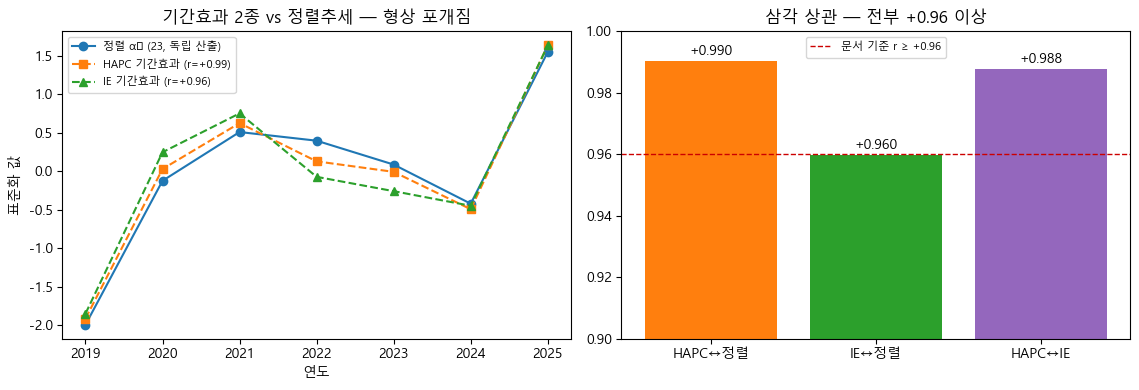

HAPC↔정렬 r=+0.990 · IE↔정렬 r=+0.960 · HAPC↔IE r=+0.988


In [3]:
yrs_l, alpha_pts = T.latent_trend_points(panel)
r_ha = float(np.corrcoef(pe_h, alpha_pts)[0, 1])
r_ia = float(np.corrcoef(pe_i, alpha_pts)[0, 1])
r_hi = float(np.corrcoef(pe_h, pe_i)[0, 1])

def z(v):
    v = np.asarray(v, float)
    return (v - v.mean()) / v.std(ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
axes[0].plot(T.YEARS_ALL, z(alpha_pts), "o-", color="#1f77b4", label="정렬 α̂ (23, 독립 산출)")
axes[0].plot(T.YEARS_ALL, z(pe_h), "s--", color="#ff7f0e", label=f"HAPC 기간효과 (r={r_ha:+.2f})")
axes[0].plot(T.YEARS_ALL, z(pe_i), "^--", color="#2ca02c", label=f"IE 기간효과 (r={r_ia:+.2f})")
axes[0].set_title("기간효과 2종 vs 정렬추세 — 형상 포개짐")
axes[0].set_xlabel("연도"); axes[0].set_ylabel("표준화 값"); axes[0].legend(fontsize=8)

pairs = ["HAPC↔정렬", "IE↔정렬", "HAPC↔IE"]
vals = [r_ha, r_ia, r_hi]
axes[1].bar(pairs, vals, color=["#ff7f0e", "#2ca02c", "#9467bd"])
axes[1].axhline(0.96, ls="--", color="#c00", lw=1, label="문서 기준 r ≥ +0.96")
axes[1].set_ylim(0.9, 1.0); axes[1].set_title("삼각 상관 — 전부 +0.96 이상")
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.002, f"{v:+.3f}", ha="center", fontsize=10)
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"HAPC↔정렬 r={r_ha:+.3f} · IE↔정렬 r={r_ia:+.3f} · HAPC↔IE r={r_hi:+.3f}")

**관찰**: 서로 무관한 세 절차 — ① 정렬법(측정모형, 응답자 원자료), ② HAPC(임의효과 수축, cap 프레임), ③ IE(영공간 제약, 가중 셀 평균) — 가 같은 연도 굴곡(2021 고점·2024 저점·2025 반등)을 낸다. 하나의 가정이 만든 무늬라면 나머지 둘이 따라올 이유가 없다 — **"상승은 기간(시대) 효과"의 증거는 어느 한 모형이 아니라 이 포개짐 자체**다. 남는 유보: 효과의 절대 수준은 여전히 식별 가정 의존이라 형상·순위만 해석한다(`24` DB③).

## **5. [입증] 검증 셀**

In [4]:
# (a) 기간효과 ↔ 인용 상수 — 전 원소 ±0.005 (결정적 재현)
for y in T.YEARS_ALL:
    assert abs(hapc["period_re"][y] - P.PERIOD_HAPC[y]) <= 5e-3, f"HAPC {y}"
    assert abs(ie["period"][y] - P.PERIOD_IE[y]) <= 5e-3, f"IE {y}"
print("(a) HAPC·IE 기간효과 14원소 ↔ PERIOD_HAPC/IE 상수 ±0.005 전부 일치 PASS")

# (b) 삼각 상관 — 문서(24 §6): +0.990 / +0.960 / +0.988
assert abs(r_ha - 0.990) <= 0.01 and abs(r_ia - 0.960) <= 0.01 and abs(r_hi - 0.988) <= 0.01
print(f"(b) 삼각 상관 ({r_ha:+.3f}/{r_ia:+.3f}/{r_hi:+.3f}) ↔ 문서(+0.990/+0.960/+0.988) PASS")

# (c) IE 수치 안정성 — 영공간 처리 정상(rank_ok)
assert ie.get("rank_ok"), "IE 설계행렬 rank 이상"
print("(c) IE rank_ok = True — 영공간 1차원 처리 정상 PASS")

# (d) 프레임 계보 — cap=6,000 (16 §4와 동일)
assert int((frame["period"] == 2022).sum()) <= 6000
print("(d) APC 프레임 2022 cap ≤ 6,000 PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) HAPC·IE 기간효과 14원소 ↔ PERIOD_HAPC/IE 상수 ±0.005 전부 일치 PASS
(b) 삼각 상관 (+0.990/+0.960/+0.988) ↔ 문서(+0.990/+0.960/+0.988) PASS
(c) IE rank_ok = True — 영공간 1차원 처리 정상 PASS
(d) APC 프레임 2022 cap ≤ 6,000 PASS

검증 (a)~(d) 전부 PASS


## **6. 종합 — 무엇을 말하고 무엇을 유보하는가**

### **연구질문 답**

- **Q1** — 식별 문제는 기간=연령+코호트 항등식이 만드는 구조적 비식별이다. 간격차 설계는 항등식을 흐릴 뿐 소거하지 못하므로 '부분완화'가 정확한 표현이고, 본 파이프라인은 그 이상을 주장하지 않는다(§1).
- **Q2** — 낸다. 가정이 무관한 HAPC와 IE의 기간효과가 r=+0.988로 포개지고, 재적합 값이 인용 상수와 전 원소 일치한다(§3·§5 (a)).
- **Q3** — 포개진다. HAPC↔정렬 +0.990, IE↔정렬 +0.960(§4) — 측정모형·임의효과·영공간이라는 세 갈래 절차의 수렴이 "상승 = 시대의 효과"를 떠받친다. **유보**: 효과 절대 수준·"유의성" 표현·APC 3효과의 인과 해석.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 1~2 | 식별 구조·방법 가정 대비(DB①) | 설계 근거 |
| 3 | HAPC·IE 재적합 + 상수 대조 | 14원소 일치 |
| 4 | 삼각 상관 재계산 [시각화] | r ≥ +0.96 |
| 5 | 일괄 assert | **PASS** |

**다음**: `28`(코호트 구배 심층) — 기간효과와 독립인 두 번째 발견으로.